<a href="https://colab.research.google.com/github/626-NRB/ADAS-Data-Analysis-07132026/blob/main/Crash_Data_Activity_07132026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import the models in the following cell. Run the cell below to proceed.

In [3]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import scipy.stats as scp
import seaborn as sb
import matplotlib.pyplot as plt
!pip install pyreadstat
!pip install researchpy
import researchpy as rp


Read the dataset. If error arises, make sure to reupload the file and update the file path if neccesary. Run the below cell to read the dataset. Proceed when the cell runs without error.

In [4]:
SGO_IR21 = pd.read_csv('/content/SGO-2021-01_Incident_Reports_ADAS.csv')

# **ALL THE QUESTIONS ARE BELOW THIS TEXT ↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓**

### A. *What is the distribution of roadways in the incident reports? [Check the field 52: &lt;Roadway Type&gt; and try to plot bar chart by types and develop count tables]*

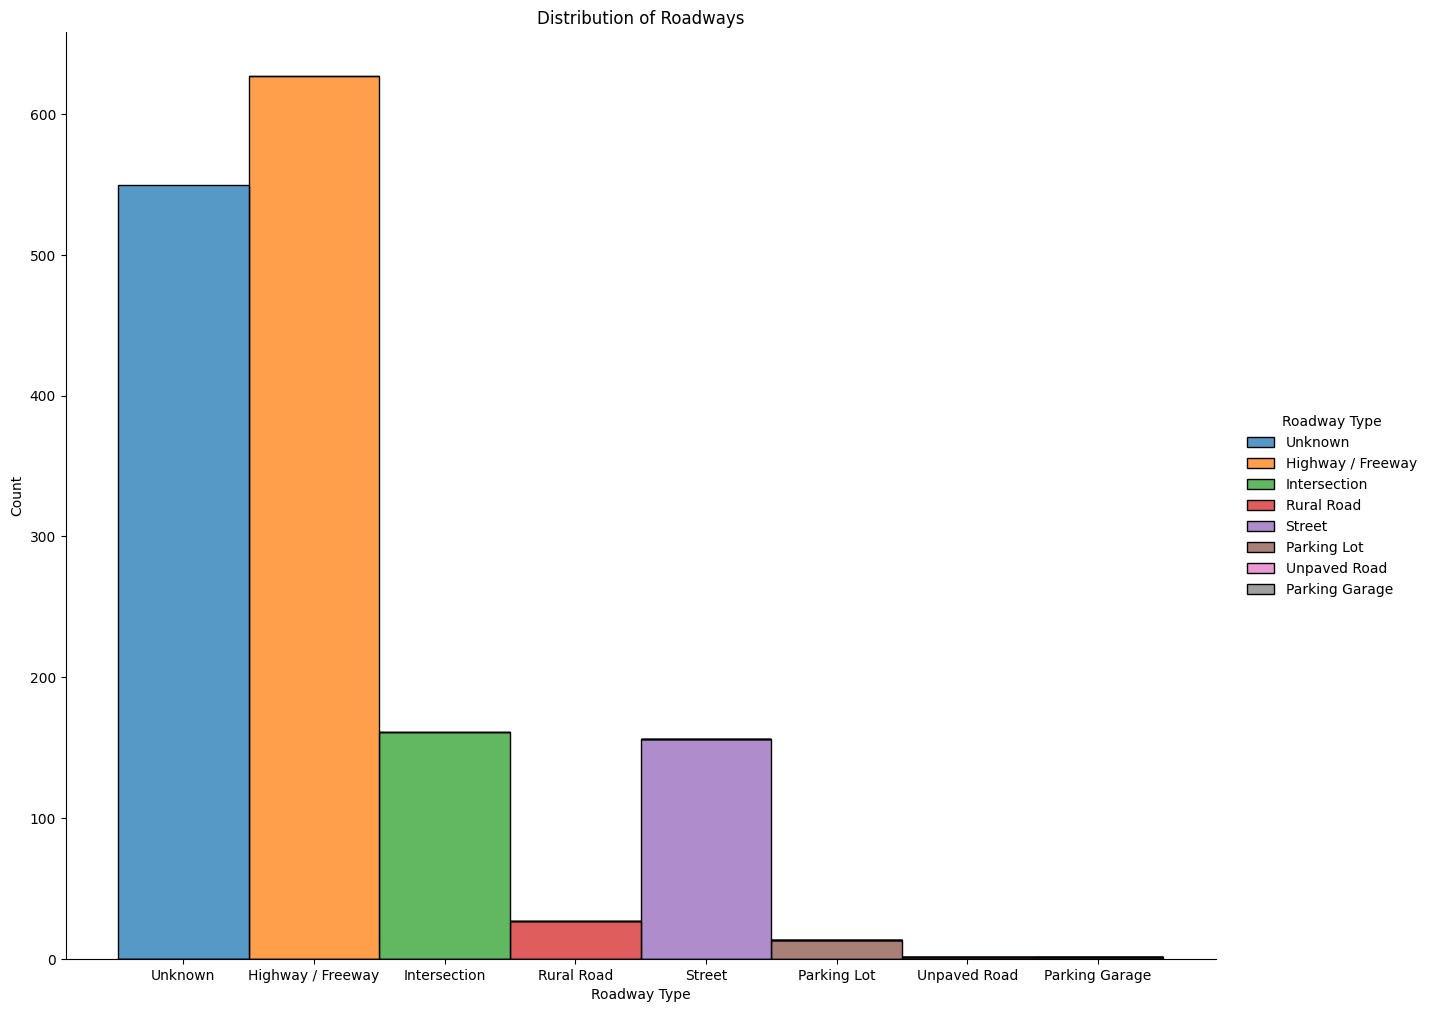

In [5]:
p = sb.displot(SGO_IR21, x='Roadway Type', hue='Roadway Type', multiple="stack", height=10, aspect=1.25)
plt.title('Distribution of Roadways')
plt.show()

### Question: What do you think about the <Unknown< road types?  What might be happening here?

In [6]:
roadway_col = SGO_IR21.columns[51]

clean_roadway = SGO_IR21[roadway_col].astype(str).str.strip()
clean_roadway = clean_roadway.replace('', 'UNKNOWN')

count_table = clean_roadway.value_counts().reset_index()
count_table.columns = ['Roadway Type', 'Incident Count']
count_table['Percentage (%)'] = ((count_table['Incident Count'] / len(SGO_IR21)) * 100).round(2)

print(count_table.to_string(index=False))

     Roadway Type  Incident Count  Percentage (%)
Highway / Freeway             627           40.82
          Unknown             550           35.81
     Intersection             161           10.48
           Street             156           10.16
       Rural Road              27            1.76
      Parking Lot              13            0.85
     Unpaved Road               1            0.07
   Parking Garage               1            0.07


### B. *What is the role of existing road or traffic conditions on the incidents?  [Create new variable/column using the fields 53, 54, 55, and 57; and try to answer the question]*

In [7]:
col_degraded = SGO_IR21.columns[52]  # Column 53: Roadway-Degraded Surface
col_markings = SGO_IR21.columns[53]  # Column 54: Roadway-Missing/Degraded Marking
col_normal   = SGO_IR21.columns[54]  # Column 55: Roadway-No Unusual Conditions
col_incident = SGO_IR21.columns[56]  # Column 57: Roadway-Traffic Incident

print("Mapping the following columns to create the new variables:")
print(f"col_degraded")
print(f"col_markings")
print(f"col_normal")
print(f"col_incident")

def determine_road_condition(row):
    conditions = []
    if str(row[col_normal]).strip().upper() == 'Y':
        conditions.append("Normal/No Unusual Conditions")
    if str(row[col_degraded]).strip().upper() == 'Y':
        conditions.append("Degraded Surface")
    if str(row[col_markings]).strip().upper() == 'Y':
        conditions.append("Missing/Degraded Markings")
    if str(row[col_incident]).strip().upper() == 'Y':
        conditions.append("Active Traffic Incident")

    if not conditions:
        return "Unknown/Other"
    elif len(conditions) > 1:
        if "Normal/No Unusual Conditions" in conditions:
            conditions.remove("Normal/No Unusual Conditions")
        return " & ".join(conditions) if len(conditions) > 1 else conditions[0]
    else:
        return conditions[0]

SGO_IR21['Road_Condition_Category'] = SGO_IR21.apply(determine_road_condition, axis=1)

stats = SGO_IR21['Road_Condition_Category'].value_counts().reset_index()
stats.columns = ['Road Condition Category', 'Incident Count']
stats['Percentage (%)'] = ((stats['Incident Count'] / len(SGO_IR21)) * 100).round(2)

print("=== Descriptive Statistics: Role of Road & Traffic Conditions ===")
print(stats)

Mapping the following columns to create the new variables:
col_degraded
col_markings
col_normal
col_incident
=== Descriptive Statistics: Role of Road & Traffic Conditions ===
        Road Condition Category  Incident Count  Percentage (%)
0                 Unknown/Other             925           60.22
1  Normal/No Unusual Conditions             572           37.24
2       Active Traffic Incident              38            2.47
3     Missing/Degraded Markings               1            0.07


***Answer to Question B:***
When we do not account for the Unknowns in the dataset, we can see that when the conditions are normal, that is where accidents are most frequent. Otherwise, accidents are most frequent in unknown situations.

C. Do we have incidents in work zones? [Check field 60, and build your own
descriptive statistics]

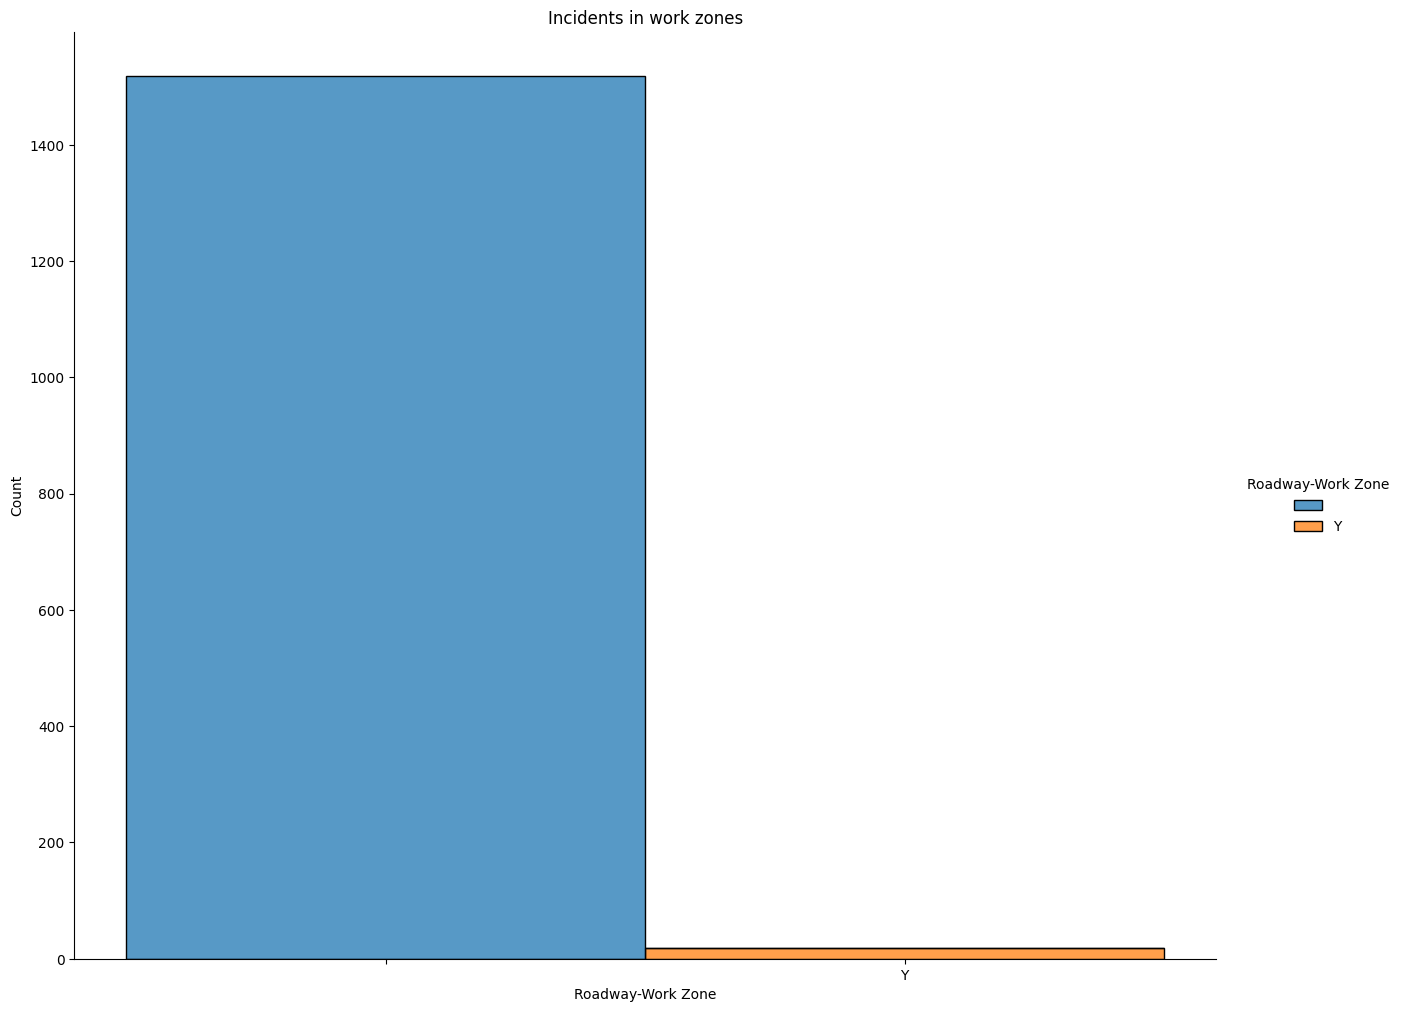

In [8]:
p = sb.displot(SGO_IR21, x='Roadway-Work Zone', hue='Roadway-Work Zone', multiple="stack", height=10, aspect=1.25)
plt.title('Incidents in work zones')
plt.show()

In [9]:
work_zone_col = SGO_IR21.columns[59]

clean_work_zone = SGO_IR21[work_zone_col].astype(str).str.strip()
clean_work_zone = clean_work_zone.replace('', 'N (Not Marked)')

work_zone_counts = clean_work_zone.value_counts().reset_index()
work_zone_counts.columns = ['Roadway - Work Zone', 'Incident Count']
work_zone_counts['Percentage (%)'] = ((work_zone_counts['Incident Count'] / len(SGO_IR21)) * 100).round(2)

print(work_zone_counts.to_string(index=False))

Roadway - Work Zone  Incident Count  Percentage (%)
     N (Not Marked)            1518           98.83
                  Y              18            1.17


D. How did weather related factors affect the incidents? [Check field 61- 71, and
build your own descriptive statistics]

In [10]:
weather_cols = SGO_IR21.columns[60:71]

# Count occurrences of 'Y' (or 'y') in each of these columns
weather_counts = {}
total_records = len(SGO_IR21)

for col in weather_cols:
    # Standardize to uppercase and strip whitespace to ensure matching
    clean_series = SGO_IR21[col].astype(str).str.strip().str.upper()
    count_y = (clean_series == 'Y').sum()
    weather_counts[col] = count_y

weather_df = pd.DataFrame(list(weather_counts.items()), columns=['Weather Condition', 'Incident Count'])
weather_df['Percentage (%)'] = ((weather_df['Incident Count'] / total_records) * 100).round(2)

# Sort by count in descending order
weather_df = weather_df.sort_values(by='Incident Count', ascending=False)

print("=== Descriptive Statistics: Weather-Related Factors ===")
print(weather_df.to_string(index=False))

multi_weather = SGO_IR21[weather_cols].apply(lambda row: (row.astype(str).str.strip().str.upper() == 'Y').sum(), axis=1)
print(f"\nIncidents with multiple weather conditions reported: {len(SGO_IR21[multi_weather > 1])} ({round((len(SGO_IR21[multi_weather > 1])/total_records)*100, 2)}%)")

=== Descriptive Statistics: Weather-Related Factors ===
            Weather Condition  Incident Count  Percentage (%)
Weather - Unk - See Narrative             561           36.52
              Weather - Clear             534           34.77
             Weather - Cloudy             373           24.28
               Weather - Rain             111            7.23
      Weather - Partly Cloudy              36            2.34
     Weather - Fog/Smoke/Haze               9            0.59
               Weather - Snow               4            0.26
        Weather - Severe Wind               1            0.07
         Weather - Dust Storm               0            0.00
   Weather - Severe Hurricane               0            0.00
   Weather - Structure-Indoor               0            0.00

Incidents with multiple weather conditions reported: 91 (5.92%)


E. What is the most crash-with (the ADAS hits which other entity) group? [Check
field 72; and build your own descriptive statistics]

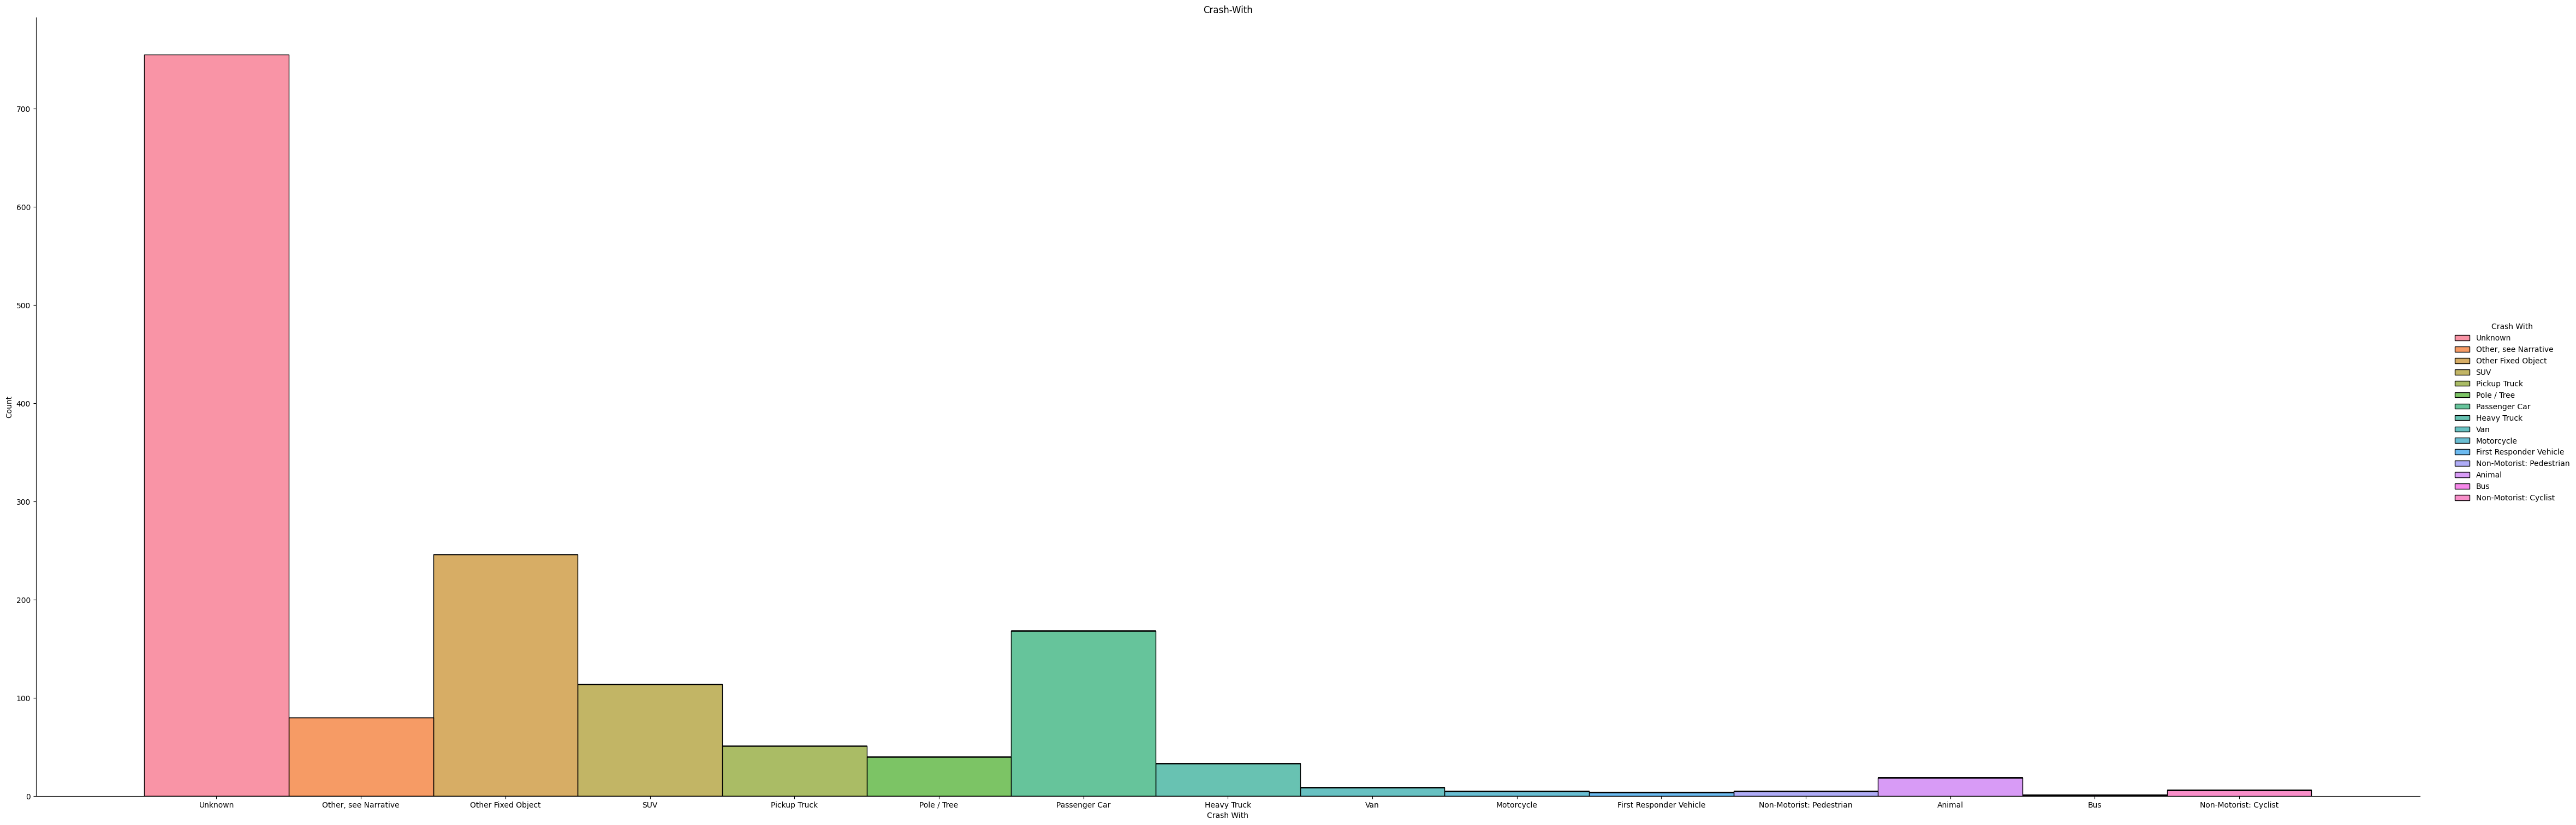

In [11]:
p = sb.displot(SGO_IR21, x='Crash With', hue='Crash With', multiple="stack", height=15, aspect=3)
plt.title('Crash-With')
plt.show()

In [12]:
roadway_col = SGO_IR21.columns[51]

roadway_counts = SGO_IR21[roadway_col].value_counts().reset_index()
roadway_counts.columns = ['Roadway Type', 'Incident Count']

total_records = len(SGO_IR21)
roadway_counts['Percentage (%)'] = ((roadway_counts['Incident Count'] / total_records) * 100).round(2)

print(roadway_counts.to_string(index=False))

     Roadway Type  Incident Count  Percentage (%)
Highway / Freeway             627           40.82
          Unknown             550           35.81
     Intersection             161           10.48
           Street             156           10.16
       Rural Road              27            1.76
      Parking Lot              13            0.85
     Unpaved Road               1            0.07
   Parking Garage               1            0.07


F. What are the outcomes from the incidents [Check field 73, and build your own
descriptive statistics]?

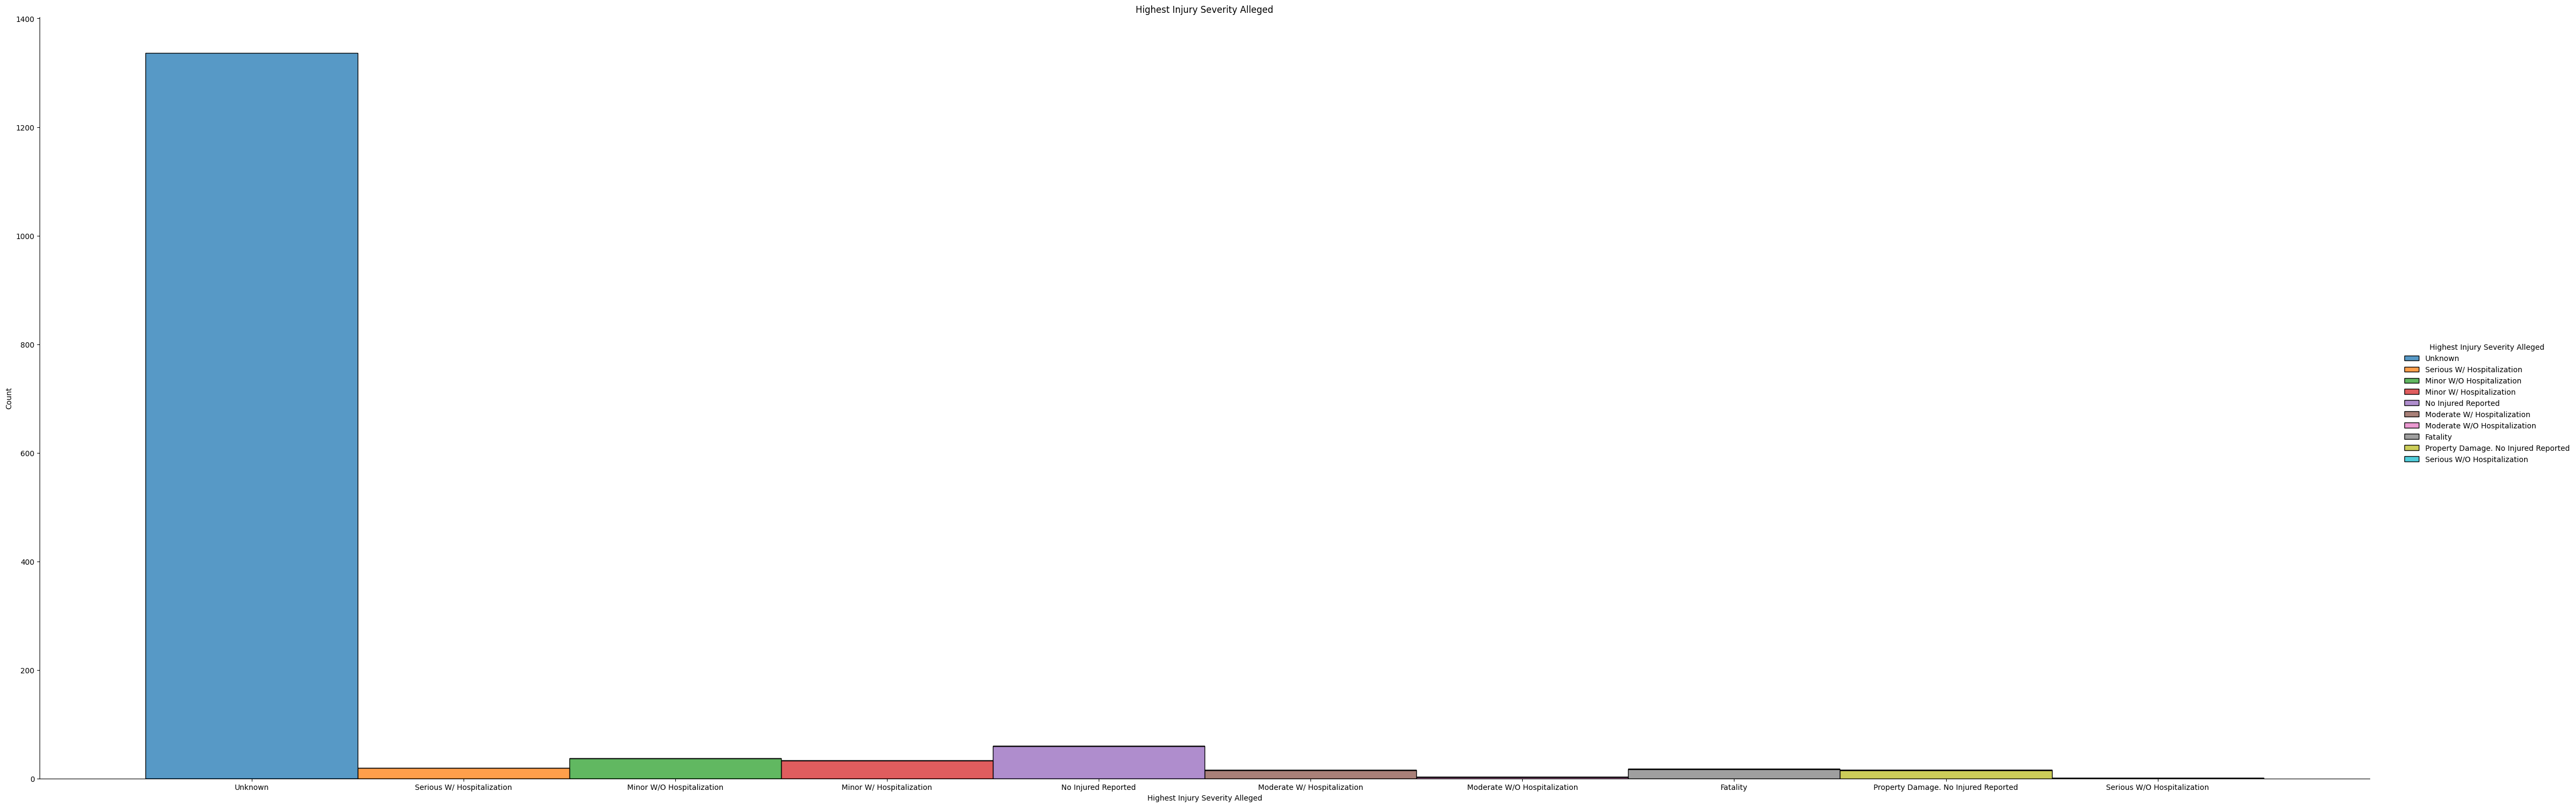

In [13]:
p = sb.displot(SGO_IR21, x='Highest Injury Severity Alleged', hue='Highest Injury Severity Alleged', multiple="stack", height=15, aspect=3)
plt.title('Highest Injury Severity Alleged')
plt.show()

In [16]:
import pandas as pd

p = SGO_IR21[SGO_IR21['Highest Injury Severity Alleged'] != 'Unknown']

# Generate frequency counts
table = p['Highest Injury Severity Alleged'].value_counts().reset_index()
table.columns = ['Highest Injury Severity Alleged', 'Count']

# Calculate relative percentages
table['Percentage (%)'] = (table['Count'] / table['Count'].sum() * 100).round(2)

print(table.to_string(index=False))

     Highest Injury Severity Alleged  Count  Percentage (%)
                 No Injured Reported     60            30.0
           Minor W/O Hospitalization     37            18.5
            Minor W/ Hospitalization     33            16.5
          Serious W/ Hospitalization     19             9.5
                            Fatality     17             8.5
         Moderate W/ Hospitalization     15             7.5
Property Damage. No Injured Reported     15             7.5
        Moderate W/O Hospitalization      3             1.5
         Serious W/O Hospitalization      1             0.5


G. What are the most common crash patterns? [Check field 74 and 86, and build
your own descriptive statistics; you need to do some data manipulation and think
about the information]

In [14]:
# Start by creating a copy with rows that don't have missing values in these columns
filtered_df = SGO_IR21.dropna(subset=["CP Pre-Crash Movement", "SV Pre-Crash Movement"]).copy()

# Clean up whitespace and ensure string type
filtered_df["CP Pre-Crash Movement"] = filtered_df["CP Pre-Crash Movement"].astype(str).str.strip()
filtered_df["SV Pre-Crash Movement"] = filtered_df["SV Pre-Crash Movement"].astype(str).str.strip()

# Exclude empty strings and any values containing the word "Unknown"
filtered_df = filtered_df[
    (filtered_df["CP Pre-Crash Movement"] != "") &
    (~filtered_df["CP Pre-Crash Movement"].str.contains("Unknown", case=False)) &
    (filtered_df["SV Pre-Crash Movement"] != "") &
    (~filtered_df["SV Pre-Crash Movement"].str.contains("Unknown", case=False))
]

print("=== CP Pre-Crash Movement Distribution (Unknowns Eliminated) ===")
print(filtered_df["CP Pre-Crash Movement"].value_counts().to_string())

print("\n=== SV Pre-Crash Movement Distribution (Unknowns Eliminated) ===")
print(filtered_df["SV Pre-Crash Movement"].value_counts().to_string())

print("\n=== Most Common Crash Patterns (SV Movement vs. CP Movement) ===")

# Group, count, and sort
crash_patterns = (
    filtered_df.groupby(["SV Pre-Crash Movement", "CP Pre-Crash Movement"])
    .size()
    .reset_index(name="Count")
    .sort_values(by="Count", ascending=False)
)

# Calculate percentage based on the new filtered dataset total
crash_patterns["Percentage"] = (
    (crash_patterns["Count"] / len(filtered_df)) * 100
).round(2)

print(crash_patterns.head(15).to_string(index=False))

=== CP Pre-Crash Movement Distribution (Unknowns Eliminated) ===
CP Pre-Crash Movement
Proceeding Straight            177
Stopped                         47
Making Left Turn                46
Lane / Road Departure           40
Other, see Narrative            37
Changing Lanes                  25
NM Crossing Roadway             13
Parked                          11
Making Right Turn                8
Passing                          7
Traveling Wrong Way              6
Crossing into Opposing Lane      3
Merging                          1
Entering Traffic                 1

=== SV Pre-Crash Movement Distribution (Unknowns Eliminated) ===
SV Pre-Crash Movement
Proceeding Straight            294
Lane / Road Departure           42
Making Left Turn                36
Making Right Turn               16
Stopped                         15
Other, see Narrative            12
Changing Lanes                   5
Crossing into Opposing Lane      1
Merging                          1

=== Most Common Cra